# PythonCodeLABook 3.16.26 willn2
- Python companion to MATLAB scripts used in LABook.
- Each cell will be mostly self contained, but will all require importing the numpy and matplotlib libraries. Run the next cell now.
- Tips and tricks: shift+enter runs current cell and moves to the next. ctrl+enter runs current cell. ctrl+'/' is comment/uncomment

In [1]:
# Import numpy and matplotlib
import numpy as np # numerical python package. Ex: Lets us define n-dimensional arrays and work with them using LA
from matplotlib import pyplot as plt # Figure generating package. Works similarly to MATLAB's figure generation

## Exercise E8.6: Recording frequency 

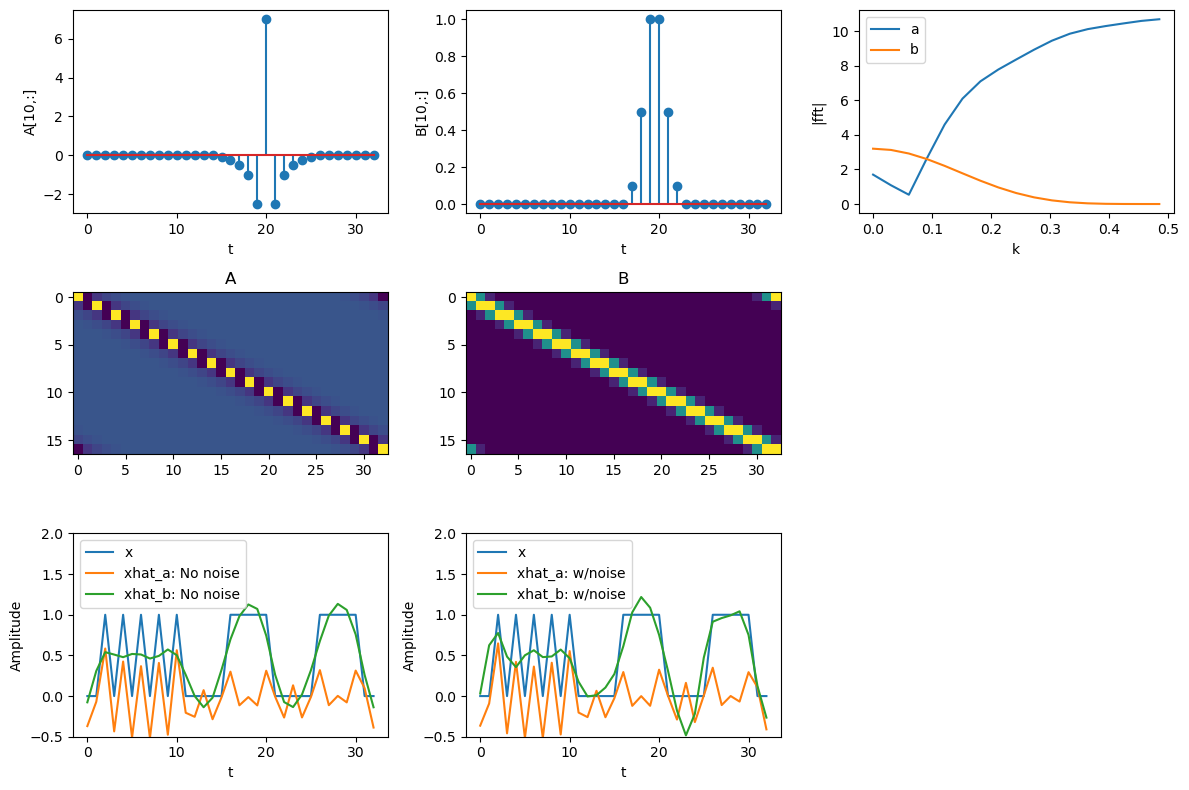

In [92]:
from numpy import fft as fft # Import fft from numpy
# Generate two impulse responses:
a, b, t = np.zeros((1,33)), np.zeros((1,33)), np.arange(0,33) # start with zero vectors. In python you have to index the first channel in a 1xn array. 

# Add in specific values for a and b in time domain
a[0,0:6], a[0,-5:] = np.array([7.0, -2.5, -1.0, -0.5, -0.25, -0.1]), np.array([-0.1, -0.25, -0.5, -1.0, -2.5]) # a ',' separates each part
b[0,0:3], b[0,-3:] = np.array([1.0, 0.5, 0.1]), np.array([0.1, 0.5, 1.0]) 

# frq domain impulse response
u = np.arange(0,0.5/(t[1]-t[0]),1/len(t)) # + frq axis
fa, fb = np.abs(fft.fft(a)), np.abs(fft.fft(b)) # frq response of system (impulse response spectra)

# Generate circulant matrices for convolution operation
num_rows = np.arange(3,N+2,2)
A, B, N, icnt = np.zeros((len(num_rows)+1,len(a[0,:]))), np.zeros((len(num_rows)+1,len(b[0,:]))), len(b[0,:]), 0
A[0,:], B[0,:] = a, b
for j in num_rows:
    icnt = int((j+1)/2)-1
    A[icnt,0:j-1] = a[0,N-j+1:]
    A[icnt,j-1:] = a[0,0:N-j+1]
    B[icnt,0:j-1] = b[0,N-j+1:]
    B[icnt,j-1:] = b[0,0:N-j+1]
    
# Generate input function
x = np.zeros((1,len(t))) # initialize
x[0,2:12:2] =  np.array([1, 1, 1, 1, 1]) 
x[0,16:21] = np.array([1, 1, 1, 1, 1]) 
x[0,26:31]  = np.array([1, 1, 1, 1, 1]) # assign signal intensity 
n = 0.2*np.random.randn(icnt+1,1) # additive noise

y1A, y1B, y2A, y2B = A@x.T, B@x.T, A@x.T + n, B@x.T + n # '@' does matrix mult. All acquisitions are recoreded in this line

# Uncomment below to see results
# fig, ax = plt.subplots(1,2)
# ax[0].plot(y1A,label='y1A - no noise')
# ax[0].plot(y2A,label='y2A - noise')
# ax[1].plot(y1B,label='y2B - no noise')
# ax[1].plot(y2B,label='y1B - noise')
# ax[0].legend()
# ax[1].legend()


# Main Figure: I go a bit out of order here, but use the indices to match with the plot 
fig, ax = plt.subplots(3,3,figsize=(12,8))
# use imshow() to make an image of the circulant matrices
ax[1,0].imshow(A)
ax[1,0].set_title('A')

ax[1,1].imshow(B)
ax[1,1].set_title('B')

# Plot one line of each matrix (impulse response)
ax[0,0].stem(t,A[10,:])
ax[0,0].set_ylabel('A[10,:]')
ax[0,0].set_xlabel('t')

ax[0,1].stem(t,B[10,:])
ax[0,1].set_ylabel('B[10,:]')
ax[0,1].set_xlabel('t')

# frq spectra of each impulse response function
ax[0,2].plot(u,fa[0,0:icnt+1])
ax[0,2].plot(u,fb[0,0:icnt+1])
ax[0,2].set_xlabel('k')
ax[0,2].set_ylabel('|fft|')
ax[0,2].legend(('a','b'))

# Next two blocks estimate x from noise free or noisy y and impulse response A or B. 
ax[2,0].plot(t,x[0,:],label='x')
ax[2,0].plot(t,np.linalg.pinv(A)@y1A,label='xhat_a: No noise')
ax[2,0].plot(t,np.linalg.pinv(B)@y1B,label='xhat_b: No noise')
ax[2,0].set_ylim(-0.5,2)
ax[2,0].legend(loc='best')
ax[2,0].set_xlabel('t')
ax[2,0].set_ylabel('Amplitude')

ax[2,1].plot(t,x[0,:],label='x')
ax[2,1].plot(t,np.linalg.pinv(A)@y2A,label='xhat_a: w/noise')
ax[2,1].plot(t,np.linalg.pinv(B)@y2B,label='xhat_b: w/noise')
ax[2,1].set_ylim(-0.5,2)
ax[2,1].legend(loc='best')
ax[2,1].set_xlabel('t')
ax[2,1].set_ylabel('Amplitude')

# Delete unwanted blocks
fig.delaxes(ax[1, 2])
fig.delaxes(ax[2, 2])
fig.tight_layout()

## Exercise 16.19: Quantum Fourier Transform

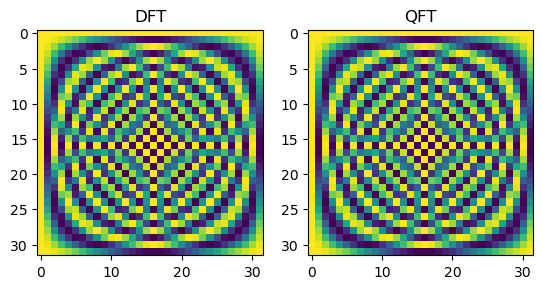

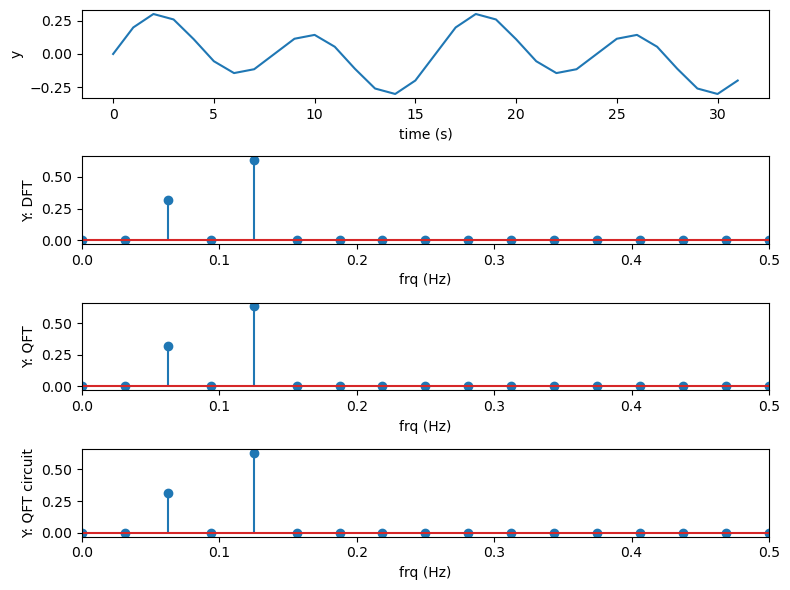

In [90]:
from numpy import pi as pi
# (a) build the DFT and QFT matrices
n = 5 # number of qubits
N = 2**n # number of basis states
q = np.exp(1j*2*pi/N) # Fourier kernel

# Initialize: J-index mat, Qd-DFT mat (complex), Qq-QFT mat (complex)
J, Qd, Qq = np.zeros((N+1,N)), np.zeros((N,N),dtype=complex), np.zeros((N,N),dtype=complex)
# J is one row larger than Qd and Qq to pull the correct indices
for ind in range(N): # form index matrix J - first row and col are zeros
    J[ind+1,:] = np.arange(0,(ind+1)*(N),ind+1) # QFT matrix index
    for k in range(N): # frequency
        Qd[ind,k] = q**(-(ind*k)) # DFT matrix (negative exponent)
        Qq[ind,k] = q**(np.mod(J[ind,k],N)) # QFT matrix (positive exponent)

# Show images of the matrices! 
fig, ax = plt.subplots(nrows=1,ncols=2) 
ax[0].imshow(np.real(Qd))
ax[0].set_title('DFT')
ax[1].imshow(np.real(Qq))
ax[1].set_title('QFT')
plt.show()

#%% Set up time and frq axis
m = np.arange(0,N) # time axis 
du, U = 1/N, 1 # frq axis params (step size, ~bandwidth)
u = np.arange(0,U,du) # frq axis

A1, frq1 = 1, 1/(N/2) # amplitude and frq of 1st sin wave
A2, frq2 = 2, 1/(N/4) # amplitude and frq of 2nd sin wave 
y = (A1*np.sin(2*pi*m*frq1)+A2*np.sin(2*pi*m*frq2)) # sum of waves
qsum = np.sum(y**2) 
y/=np.sqrt(qsum) # normalize the input energy

Yd = Qd @ y/np.sqrt(N) # DFT (matrix mult)
Yq = Qq @ y/np.sqrt(N) # QFT (matrix mult)

# Plotting just these results
fig, ax = plt.subplots(4,1, figsize=(8,6))
ax[0].plot(m,y)
ax[0].set_xlabel('time (s)')
ax[0].set_ylabel('y')
ax[1].stem(u,np.abs(Yd))
ax[1].set_xlabel('frq (Hz)')
ax[1].set_ylabel('Y: DFT')
ax[1].set_xlim(0,0.5)
ax[2].stem(u,np.abs(Yq))
ax[2].set_xlabel('frq (Hz)')
ax[2].set_ylabel('Y: QFT')
ax[2].set_xlim(0,0.5)
# fig.tight_layout()
# plt.show()

#%% (b) Program the QFT curcuit for n=5 qubits
ket0 = np.array([[1],[0]]) # basis state 0
ket1 = np.array([[0],[1]]) # basis state 1
x = np.zeros((1,n)) # dec array of bin values
Yqc = 0 

for i in range(N,2*N): # binary digit length
        yy = np.binary_repr(i) # Translate to binary
        for bit in range(n): # loop through each bit
            if yy[bit+1] =='1':
                x[0,bit] = 1
            else:
                x[0,bit] = 0
                
        X1 = ket0+ket1*np.exp(1j*2*pi*x[0,-1]/2) # LSB
        X2 = ket0+ket1*np.exp(1j*2*pi*((x[0,-2])/2+(x[0,-1])/2**2))       
        X3 = ket0+ket1*np.exp(1j*2*pi*(((x[0,-3])/2)+((x[0,-2])/2**2)+(x[0,-1])/2**3)) 
        X4 = ket0+ket1*np.exp(1j*2*pi*(((x[0,-4])/2)+((x[0,-3])/2**2)+((x[0,-2])/2**3)+(x[0,-1])/2**4)) 
        X5 = ket0+ket1*np.exp(1j*2*pi*(((x[0,-5])/2)+((x[0,-4])/2**2)+((x[0,-3])/2**3)+((x[0,-2])/2**4)+(x[0,-1])/2**5)) #MSB 
        Yqc = Yqc+y[i-N]*np.kron(X1,np.kron(X2,np.kron(X3,np.kron(X4,X5))))/(2**(n/2)) # Tensor prod and sum
# Plotting the rest!
ax[3].stem(u,np.abs(Yqc))
ax[3].set_xlabel('frq (Hz)')
ax[3].set_ylabel('Y: QFT circuit')
ax[3].set_xlim(0,0.5)
fig.tight_layout()
plt.show()